# Notebook 05 (Exp 3) — Full Fine-Tuning (FFT)

Changes vs Exp 2:
- **Unidirectional training** (Mod→Shak only) using `train_uni.jsonl`
- Same LR=5e-5 as exp2 (the key fix for the underfitting plateau)

**Model**: Qwen2.5-1.5B-Instruct  
**Output**: `outputs/exp3/fft/`

In [1]:
import sys
import gc
import json
from pathlib import Path

import torch
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path('..').resolve()))
from src.model_utils import load_model_and_tokenizer, print_model_info
from src.data_utils import load_jsonl_as_hf_dataset, load_jsonl, SYSTEM_PROMPT_MOD2SHAK
from src.training_utils import build_fft_training_args_exp2

from trl import SFTTrainer

ROOT          = Path('..').resolve()
PROCESSED_DIR = ROOT / 'data' / 'processed'
HF_CACHE      = ROOT / 'data' / 'raw' / 'huggingface_cache'
OUTPUT_DIR    = ROOT / 'outputs' / 'exp3' / 'fft'
FIG_DIR       = ROOT / 'outputs' / 'exp3' / 'results' / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

MODEL_ID = 'Qwen/Qwen2.5-1.5B-Instruct'
print('Setup complete.')
print(f'GPU:  {torch.cuda.get_device_name(0)}')
print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')


Setup complete.
GPU:  NVIDIA RTX PRO 5000 Blackwell
VRAM: 50.8 GB


## 1. Load Unidirectional Training Split

Re-uses `train_uni.jsonl` built by notebook 04 (Exp 3). If not present, builds it now.

In [2]:
UNI_TRAIN = PROCESSED_DIR / 'train_uni.jsonl'

if not UNI_TRAIN.exists():
    print('Building train_uni.jsonl (run 04_exp3_lora_training first, or building now) ...')
    all_records = load_jsonl(PROCESSED_DIR / 'train.jsonl')
    uni_records = [r for r in all_records
                   if r['messages'][0]['content'] == SYSTEM_PROMPT_MOD2SHAK]
    with open(UNI_TRAIN, 'w', encoding='utf-8') as f:
        for rec in uni_records:
            f.write(json.dumps(rec, ensure_ascii=False) + '\n')
    print(f'Saved {len(uni_records):,} records.')
else:
    print(f'train_uni.jsonl found.')

train_dataset = load_jsonl_as_hf_dataset(UNI_TRAIN)
val_dataset   = load_jsonl_as_hf_dataset(PROCESSED_DIR / 'val.jsonl')
print('Train (unidirectional):', train_dataset)
print('Val:                   ', val_dataset)


Building train_uni.jsonl (run 04_exp3_lora_training first, or building now) ...
Saved 20,042 records.


Generating train split: 0 examples [00:00, ? examples/s]

Train (unidirectional): Dataset({
    features: ['messages'],
    num_rows: 20042
})
Val:                    Dataset({
    features: ['messages'],
    num_rows: 2234
})


## 2. Load Model (BF16, All Parameters Trainable)

In [3]:
model, tokenizer = load_model_and_tokenizer(
    MODEL_ID,
    quantization=None,
    attn_implementation='eager',
)
print_model_info(model)

if torch.cuda.is_available():
    print(f'VRAM after model load: {torch.cuda.memory_allocated(0)/1e9:.2f} GB')


`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

Total parameters:     1,543,714,304
Trainable parameters: 1,543,714,304  (100.00%)
VRAM after model load: 3.09 GB


## 3. Training Configuration (Exp 2 args — LR=5e-5)

In [4]:
training_args = build_fft_training_args_exp2(
    output_dir=str(OUTPUT_DIR / 'checkpoints'),
    # ~36 GB effective VRAM (other processes consume ~11 GB of 47 GB)
    per_device_train_batch_size=8,    # was 16; OOM at 16 due to ~8 GB logits alloc
    gradient_accumulation_steps=2,    # effective batch = 16 preserved
    max_length=512,
    gradient_checkpointing=True,      # re-enabled; reduces activation memory ~40%
    dataloader_num_workers=4,
)

print('Training arguments (Exp 3 FFT):')
print(f'  learning_rate:       {training_args.learning_rate}  (exp1: 2e-5)')
print(f'  num_train_epochs:    {training_args.num_train_epochs}')
print(f'  effective batch:     {training_args.per_device_train_batch_size * training_args.gradient_accumulation_steps}')
print(f'  dataset:             Unidirectional (Mod→Shak only)')

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Training arguments (Exp 3 FFT):
  learning_rate:       5e-05  (exp1: 2e-5)
  num_train_epochs:    3
  effective batch:     16
  dataset:             Unidirectional (Mod→Shak only)


## 4. Train

In [5]:
trainer = SFTTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    processing_class=tokenizer,
)

# Check if complete, or find latest checkpoint to resume
_final = OUTPUT_DIR / 'final_model'
if _final.exists():
    print(f'Training already complete — found {_final.name}')
    print('Delete final_model/ to re-train.')
    train_result = None
else:
    _ckpts = sorted(
        (OUTPUT_DIR / 'checkpoints').glob('checkpoint-*'),
        key=lambda p: int(p.name.split('-')[-1])
    ) if (OUTPUT_DIR / 'checkpoints').exists() else []
    _resume = str(_ckpts[-1]) if _ckpts else None
    print(f'Resuming from: {_resume}' if _resume else 'Starting FFT training (Exp 3: unidirectional, LR=5e-5) from scratch ...')
    train_result = trainer.train(resume_from_checkpoint=_resume)
    print(f'\nTraining complete.')
    print(f'  Train loss: {train_result.training_loss:.4f}')
    print(f'  Steps:      {train_result.global_step}')

Tokenizing train dataset:   0%|          | 0/20042 [00:00<?, ? examples/s]

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Starting FFT training (Exp 3: unidirectional, LR=5e-5) from scratch ...


Step,Training Loss,Validation Loss
200,1.017048,1.020970
400,0.870844,1.020439
600,0.783249,1.050091
627,0.783249,1.050062


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['lm_head.weight'].



Training complete.
  Train loss: 0.9340
  Steps:      627


## 5. Save Model

In [6]:
model_path = str(OUTPUT_DIR / 'final_model')
trainer.save_model(model_path)
tokenizer.save_pretrained(model_path)
print(f'FFT model (Exp 3) saved to: {model_path}')


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

FFT model (Exp 3) saved to: /home/prasingh/data/Mormon-NLT/outputs/exp3/fft/final_model


In [7]:
log_path = OUTPUT_DIR / 'training_logs' / 'fft_log_history.json'
log_path.parent.mkdir(parents=True, exist_ok=True)
if train_result is not None:
    with open(log_path, 'w') as f:
        json.dump(trainer.state.log_history, f)
    print(f'Log history saved to: {log_path}')
else:
    print('Training was skipped — log not updated.')
    if log_path.exists(): print(f'Existing log at: {log_path}')

Log history saved to: /home/prasingh/data/Mormon-NLT/outputs/exp3/fft/training_logs/fft_log_history.json


## 6. Training Loss Curve

Loaded 17 entries from fft_log_history.json.


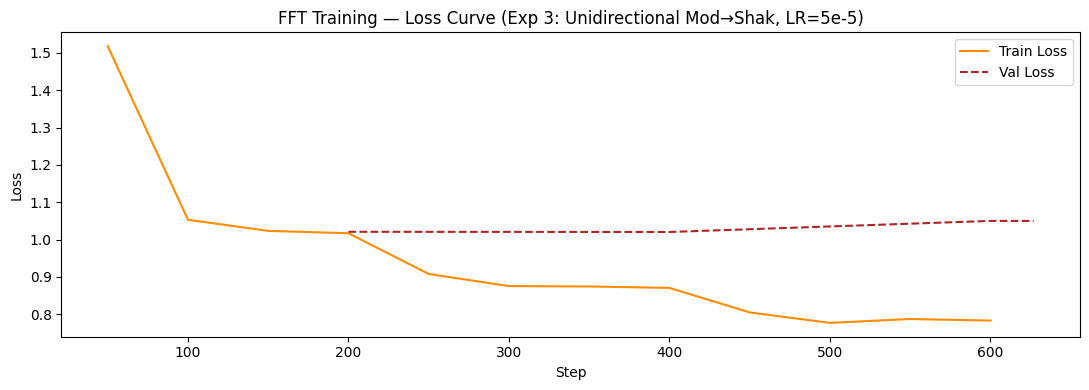

In [8]:
log_path = OUTPUT_DIR / 'training_logs' / 'fft_log_history.json'
if log_path.exists():
    with open(log_path) as f:
        log_history = json.load(f)
    print(f'Loaded {len(log_history)} entries from {log_path.name}.')
else:
    log_history = trainer.state.log_history
    print('Using in-memory trainer log history.')
log_df = pd.DataFrame(log_history)
train_loss = log_df[log_df['loss'].notna()][['step', 'loss']]
eval_loss  = log_df[log_df['eval_loss'].notna()][['step', 'eval_loss']]

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(train_loss['step'], train_loss['loss'], label='Train Loss', color='darkorange')
ax.plot(eval_loss['step'], eval_loss['eval_loss'], label='Val Loss', color='firebrick', linestyle='--')
ax.set_xlabel('Step'); ax.set_ylabel('Loss')
ax.set_title('FFT Training — Loss Curve (Exp 3: Unidirectional Mod→Shak, LR=5e-5)')
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / 'exp3_fft_loss_curve.png', dpi=150)
plt.show()


In [9]:
del model, trainer
gc.collect()
torch.cuda.empty_cache()
print('Memory freed.')


Memory freed.
